# 🎓 Career Prediction for Students — ML Pipeline
**Dataset:** 4.076 sampel | **Target:** 6 kategori karir | **Fitur:** teks skill mahasiswa  
**Workflow:** Text Preprocessing → TF-IDF → Train/Test Split → 4 Model → Evaluation → Interpretability

In [2]:
# # ── Cell 1: Install Dependencies ─────────────────────────────────────────────
%pip install xgboost shap --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ── Cell 2: Import Libraries ──────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import shap

print('✅ Semua library berhasil dimuat.')

✅ Semua library berhasil dimuat.


In [4]:
# ── Cell 3: Load Dataset ──────────────────────────────────────────────────────
# Kolom: 'Skill' (fitur teks) dan 'Career' (label target)
df = pd.read_csv('Career Dataset.csv')   # ganti path jika perlu

print(f'Shape  : {df.shape}')
print(f'Kolom  : {df.columns.tolist()}')
print(f'Missing: {df.isnull().sum().to_dict()}')
print(f"\nDistribusi Kelas (Career):")
print(df['Career'].value_counts())
df.head(3)

Shape  : (4076, 2)
Kolom  : ['Career', 'Skill']
Missing: {'Career': 0, 'Skill': 0}

Distribusi Kelas (Career):
Career
Development                                            1148
Artificial Intelligence                                 804
Software Development and Engineering                    714
Security                                                580
Data Science                                            558
User Experience (UX) and User Interface (UI) Design     272
Name: count, dtype: int64


,Career,Skill
0,Software Development and Engineering,"Web Development, Mobile App Development, Artif..."
1,Development,"Web Development, Mobile App Development, Probl..."
2,Data Science,"Data Analysis and Visualization, Deeplearning,..."


In [5]:
# ── Cell 4: Text Preprocessing ────────────────────────────────────────────────
# Langkah: lowercase → hapus tanda baca & angka → tokenisasi → hapus stopword

STOP_WORDS = {
    'and','or','the','a','an','in','of','to','is','for','with','on','at','by',
    'as','it','be','this','that','are','was','were','have','has','been','from',
    'not','but','if','so','do','can','will','would','could','should','may',
    'might','my','your','our','their','its','we','they','he','she','i','you',
    'me','him','her','us','them','what','which','who','how','when','where',
    'why','all','each','any','some','no','also','other','more','very'
}

def preprocess(text: str) -> str:
    text   = str(text).lower()                                   # 1. Lowercase
    text   = re.sub(r'[^a-z\s]', ' ', text)                      # 2. Hapus tanda baca & angka
    tokens = text.split()                                        # 3. Tokenisasi (split whitespace)
    tokens = [t for t in tokens                                  # 4. Hapus stopword & token pendek
              if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

df['Skill_Clean'] = df['Skill'].apply(preprocess)

print('Contoh preprocessing:')
print(f'  Sebelum : {df["Skill"].iloc[0][:100]}')
print(f'  Sesudah : {df["Skill_Clean"].iloc[0][:100]}')

Contoh preprocessing:
  Sebelum : Web Development, Mobile App Development, Artificial Intelligence (AI) and Machine Learning, Problem 
  Sesudah : web development mobile app development artificial intelligence ai machine learning problem solving a


In [6]:
# ── Cell 5: TF-IDF Vectorization ─────────────────────────────────────────────
# ngram_range=(1,2) → unigram + bigram untuk representasi skill lebih kaya
# sublinear_tf=True → gunakan log(1+tf) agar token frekuensi tinggi tidak dominan

vectorizer = TfidfVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),
    sublinear_tf = True
)

le = LabelEncoder()

X = vectorizer.fit_transform(df['Skill_Clean'])   # sparse matrix (4076, 5000)
y = le.fit_transform(df['Career'].astype(str))    # integer label 0–5

print(f'Dimensi TF-IDF : {X.shape}')
print(f'Pemetaan Label : {dict(zip(le.classes_, range(len(le.classes_))))}')

Dimensi TF-IDF : (4076, 5000)
Pemetaan Label : {'Artificial Intelligence': 0, 'Data Science': 1, 'Development': 2, 'Security': 3, 'Software Development and Engineering': 4, 'User Experience (UX) and User Interface (UI) Design': 5}


In [7]:
# ── Cell 6: Train-Test Split (80:20, stratified) ──────────────────────────────
# stratify=y memastikan proporsi kelas sama di train dan test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} sampel')
print(f'Test  : {X_test.shape[0]} sampel')

Train : 3260 sampel
Test  : 816 sampel


In [8]:
# ── Cell 7: Model Training ────────────────────────────────────────────────────
# 4 model dilatih dan dievaluasi; semua hasil disimpan di dict `results`

models = {
    'Naive Bayes'         : MultinomialNB(alpha=0.1),
    'Logistic Regression' : LogisticRegression(C=5, max_iter=1000, random_state=42),
    'Linear SVM'          : LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'XGBoost'             : XGBClassifier(
                                n_estimators  = 300,
                                max_depth     = 6,
                                learning_rate = 0.1,
                                eval_metric   = 'mlogloss',
                                random_state  = 42,
                                n_jobs        = -1
                            ),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model'     : model,
        'y_pred'    : y_pred,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall'    : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro'  : f1_score(y_test, y_pred, average='macro', zero_division=0),
    }
    mark = '✅' if results[name]['accuracy'] >= 0.90 else '⚠️'
    print(f"{mark} [{name}] Accuracy: {results[name]['accuracy']:.4f}")

✅ [Naive Bayes] Accuracy: 0.9240
✅ [Logistic Regression] Accuracy: 0.9485
✅ [Linear SVM] Accuracy: 0.9436
✅ [XGBoost] Accuracy: 0.9522


In [9]:
# ── Cell 8: Evaluation — Tabel Ringkasan Metrik ───────────────────────────────

summary = pd.DataFrame([
    {
        'Model'     : name,
        'Accuracy'  : round(r['accuracy'],  4),
        'Precision' : round(r['precision'], 4),
        'Recall'    : round(r['recall'],    4),
        'F1-Macro'  : round(r['f1_macro'],  4),
        '>90%?'     : '✅ Yes' if r['accuracy'] >= 0.90 else '❌ No'
    }
    for name, r in results.items()
])

print(summary.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Macro >90%?
        Naive Bayes    0.9240     0.9301  0.9255    0.9272 ✅ Yes
Logistic Regression    0.9485     0.9570  0.9488    0.9521 ✅ Yes
         Linear SVM    0.9436     0.9514  0.9445    0.9473 ✅ Yes
            XGBoost    0.9522     0.9606  0.9549    0.9574 ✅ Yes


In [10]:
# ── Cell 9: Evaluation — Classification Report per Model ─────────────────────

for name, r in results.items():
    print(f"\n{'='*65}")
    print(f"  {name}  (Accuracy: {r['accuracy']:.4f})")
    print('='*65)
    print(classification_report(
        y_test, r['y_pred'],
        target_names=le.classes_,
        zero_division=0
    ))


  Naive Bayes  (Accuracy: 0.9240)
                                                     precision    recall  f1-score   support

                            Artificial Intelligence       0.93      0.96      0.94       161
                                       Data Science       0.92      0.93      0.92       112
                                        Development       0.92      0.97      0.95       230
                                           Security       0.95      0.90      0.92       116
               Software Development and Engineering       0.88      0.80      0.84       143
User Experience (UX) and User Interface (UI) Design       0.98      1.00      0.99        54

                                           accuracy                           0.92       816
                                          macro avg       0.93      0.93      0.93       816
                                       weighted avg       0.92      0.92      0.92       816


  Logistic Regression  (Accurac

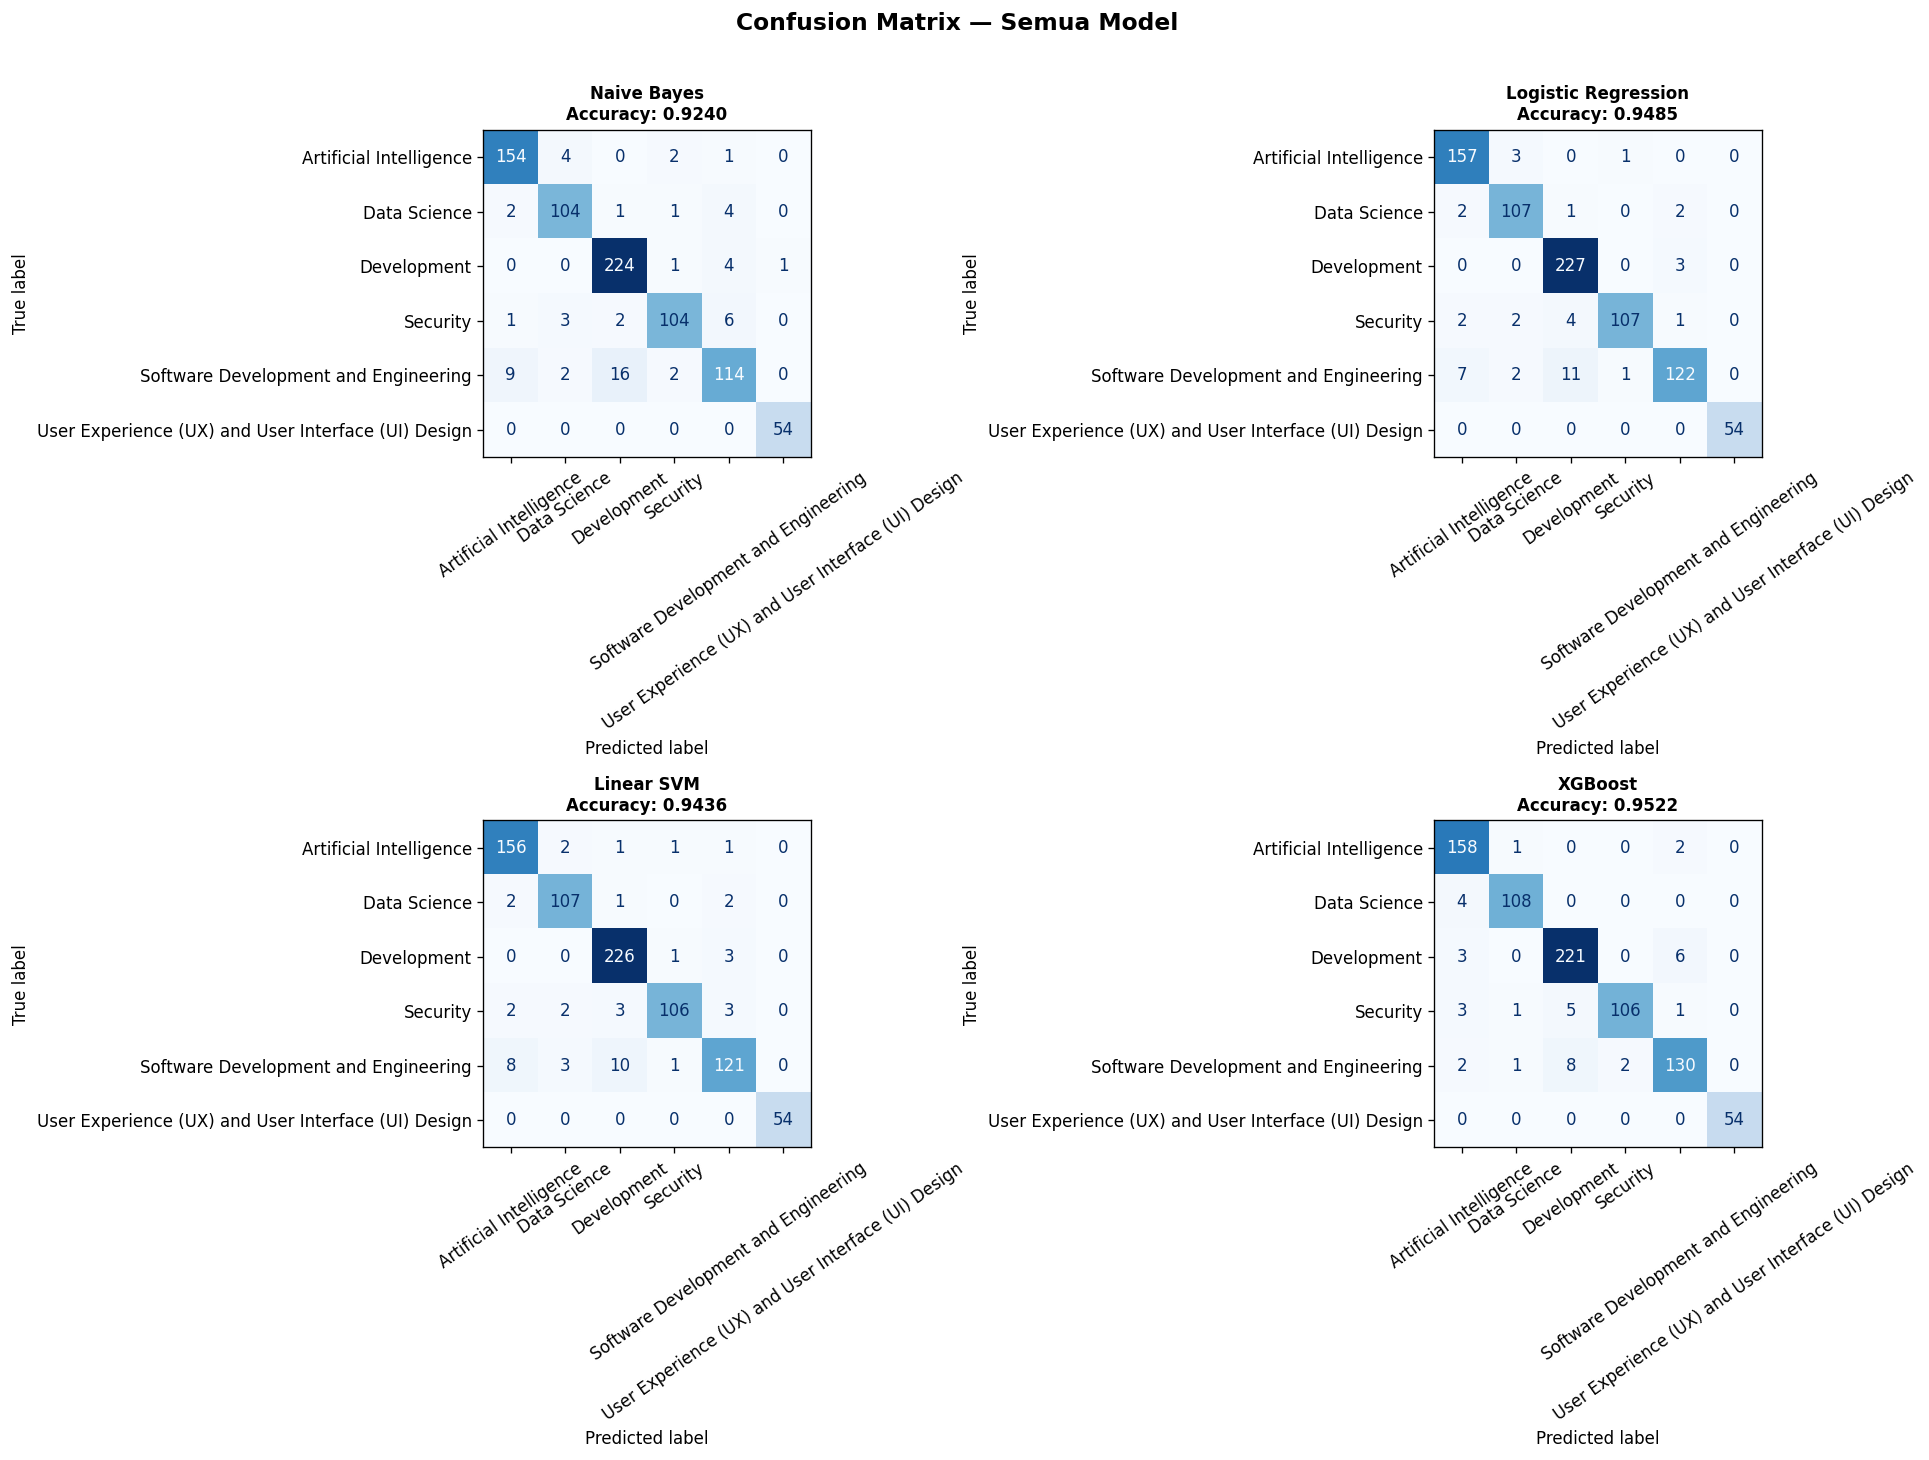

In [11]:
# ── Cell 10: Evaluation — Confusion Matrix (semua model) ─────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, xticks_rotation=35, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAccuracy: {r['accuracy']:.4f}",
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrix — Semua Model', y=1.01,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

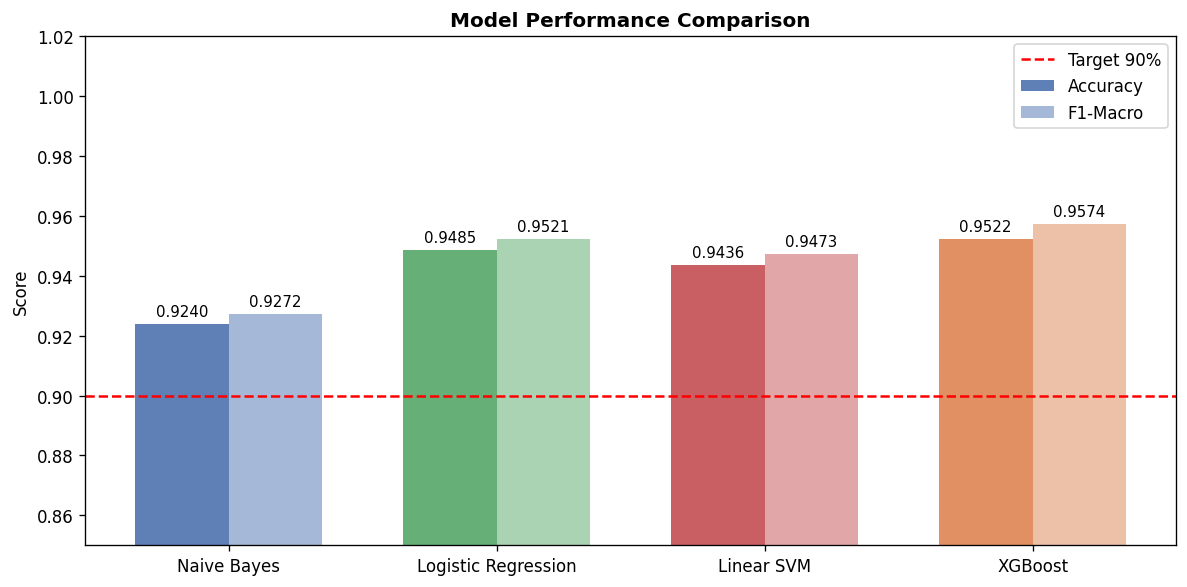

In [12]:
# ── Cell 11: Evaluation — Accuracy Bar Chart ─────────────────────────────────

names  = list(results.keys())
accs   = [results[n]['accuracy']  for n in names]
f1s    = [results[n]['f1_macro']  for n in names]
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

x      = np.arange(len(names))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, accs, width, label='Accuracy',  color=colors, alpha=0.9)
b2 = ax.bar(x + width/2, f1s,  width, label='F1-Macro',  color=colors, alpha=0.5)
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
ax.axhline(0.90, color='red', linestyle='--', linewidth=1.5, label='Target 90%')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

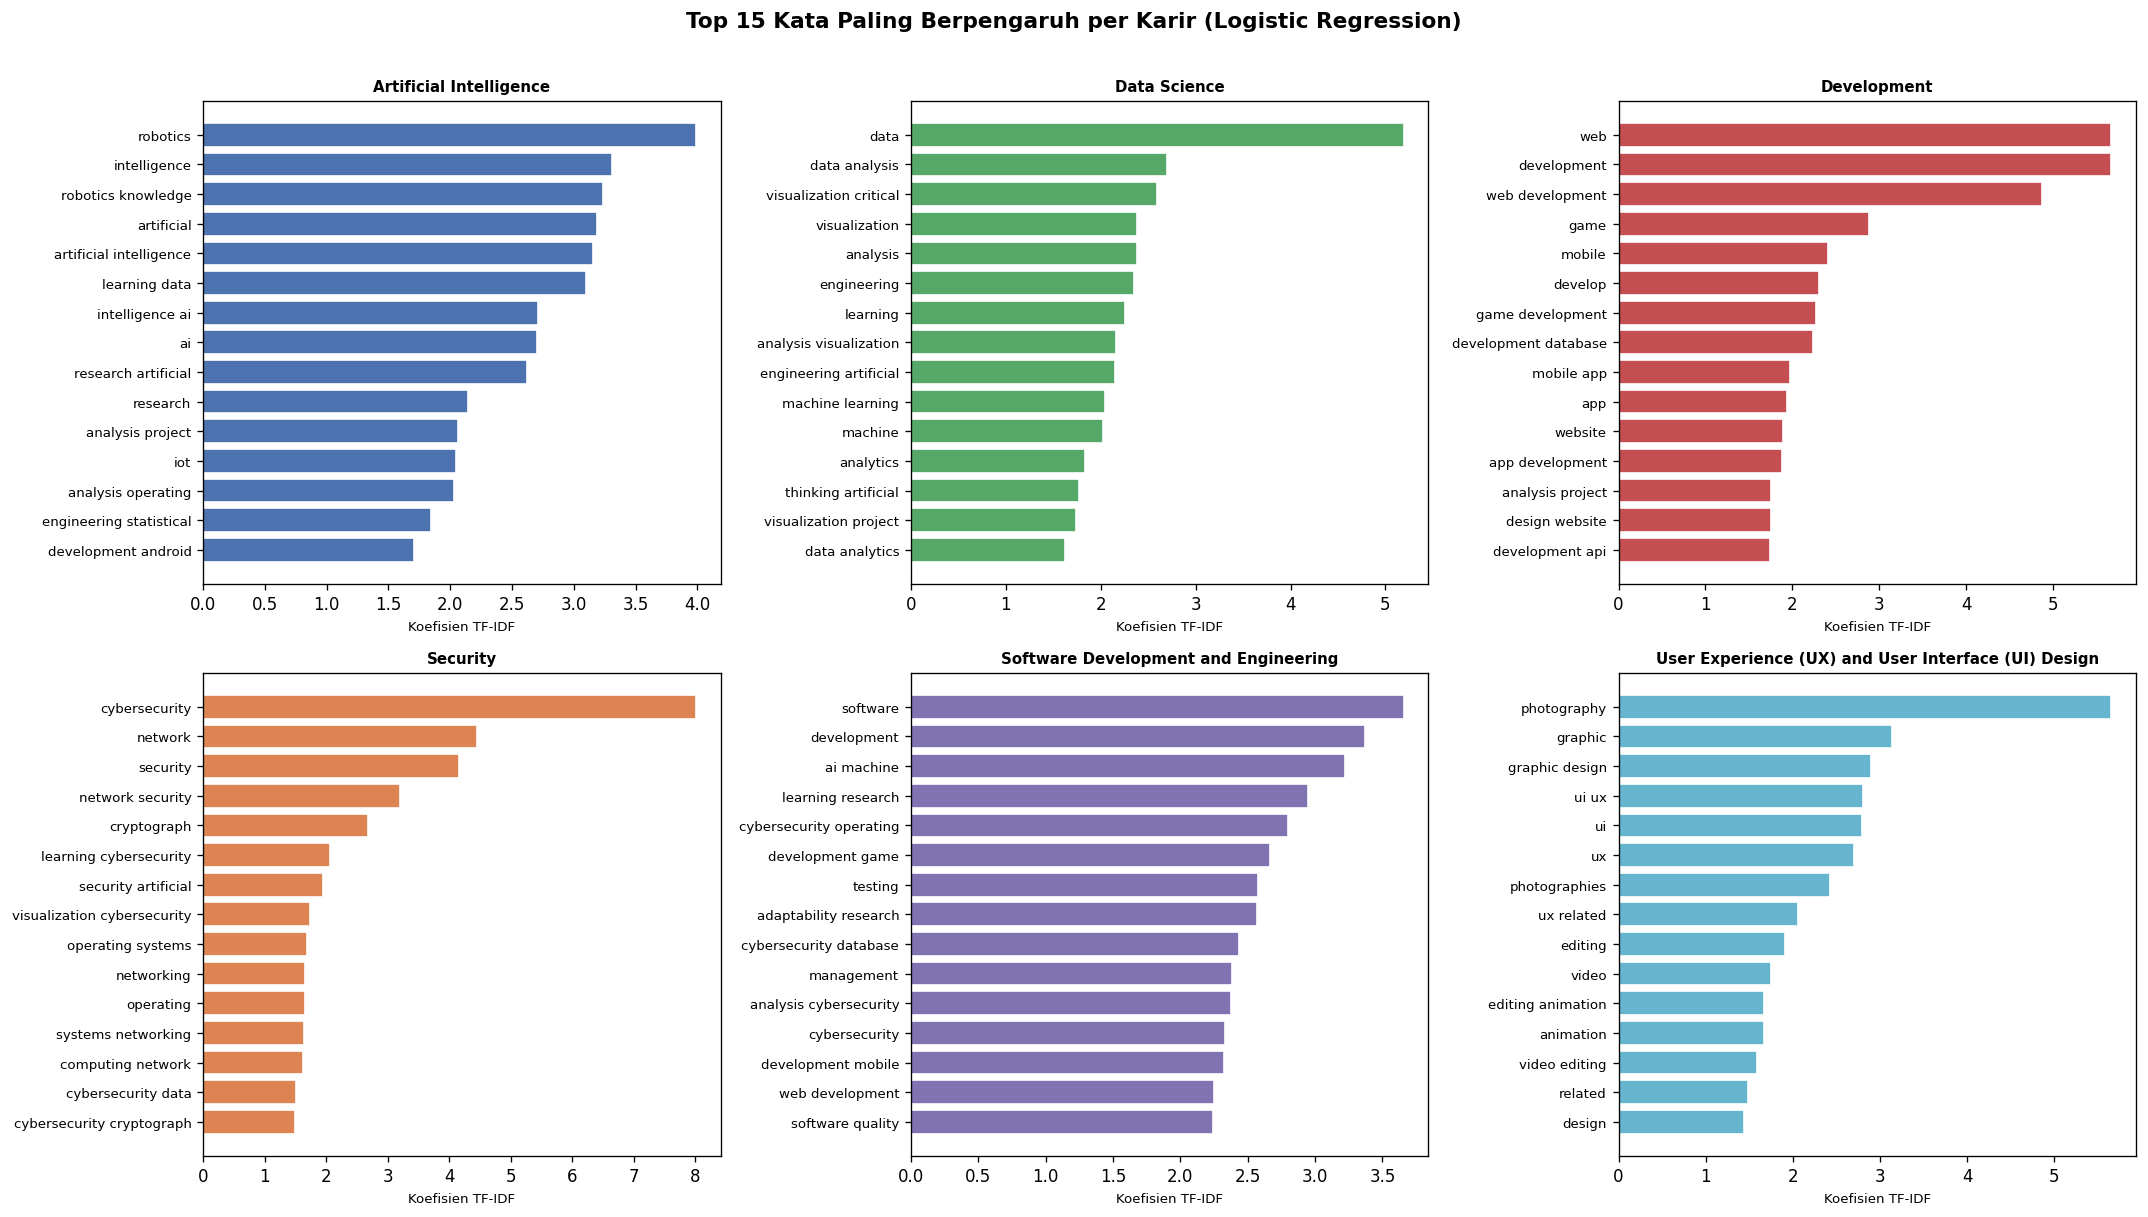

In [13]:
# ── Cell 12: Interpretability — Top Important Words per Kelas (Logistic Regression)
# Koefisien LogReg langsung menunjukkan bobot fitur per kelas → mudah diinterpretasi

lr_model   = results['Logistic Regression']['model']
feat_names = np.array(vectorizer.get_feature_names_out())
TOP_N      = 15

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes      = axes.flatten()
palette   = ['#4C72B0','#55A868','#C44E52','#DD8452','#8172B2','#64B5CD']

for i, (class_name, ax) in enumerate(zip(le.classes_, axes)):
    coef      = lr_model.coef_[i]
    top_idx   = np.argsort(coef)[-TOP_N:][::-1]
    top_words = feat_names[top_idx]
    top_vals  = coef[top_idx]

    ax.barh(range(TOP_N), top_vals[::-1], color=palette[i], edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_words[::-1], fontsize=8)
    ax.set_xlabel('Koefisien TF-IDF', fontsize=8)
    ax.set_title(class_name, fontsize=9, fontweight='bold',
                 wrap=True)

plt.suptitle('Top 15 Kata Paling Berpengaruh per Karir (Logistic Regression)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# ── Cell 13: Interpretability — SHAP Values (Linear SVM) ─────────────────────
# LinearExplainer efisien untuk model linear + sparse matrix

svm_model = results['Linear SVM']['model']

# Gunakan max 300 sampel test agar cepat
N_SAMPLE     = min(300, X_test.shape[0])
X_test_dense = X_test[:N_SAMPLE].toarray()

background   = shap.maskers.Independent(X_train, max_samples=100)
explainer    = shap.LinearExplainer(svm_model, background)
shap_vals    = explainer.shap_values(X_test_dense)

# shap_vals: list of arrays untuk multi-class, atau 2D array untuk binary
if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 2:
    shap_vals = [shap_vals]

print(f'✅ SHAP computed | Classes: {len(shap_vals)} | Shape per class: {shap_vals[0].shape}')

✅ SHAP computed | Classes: 300 | Shape per class: (5000, 6)


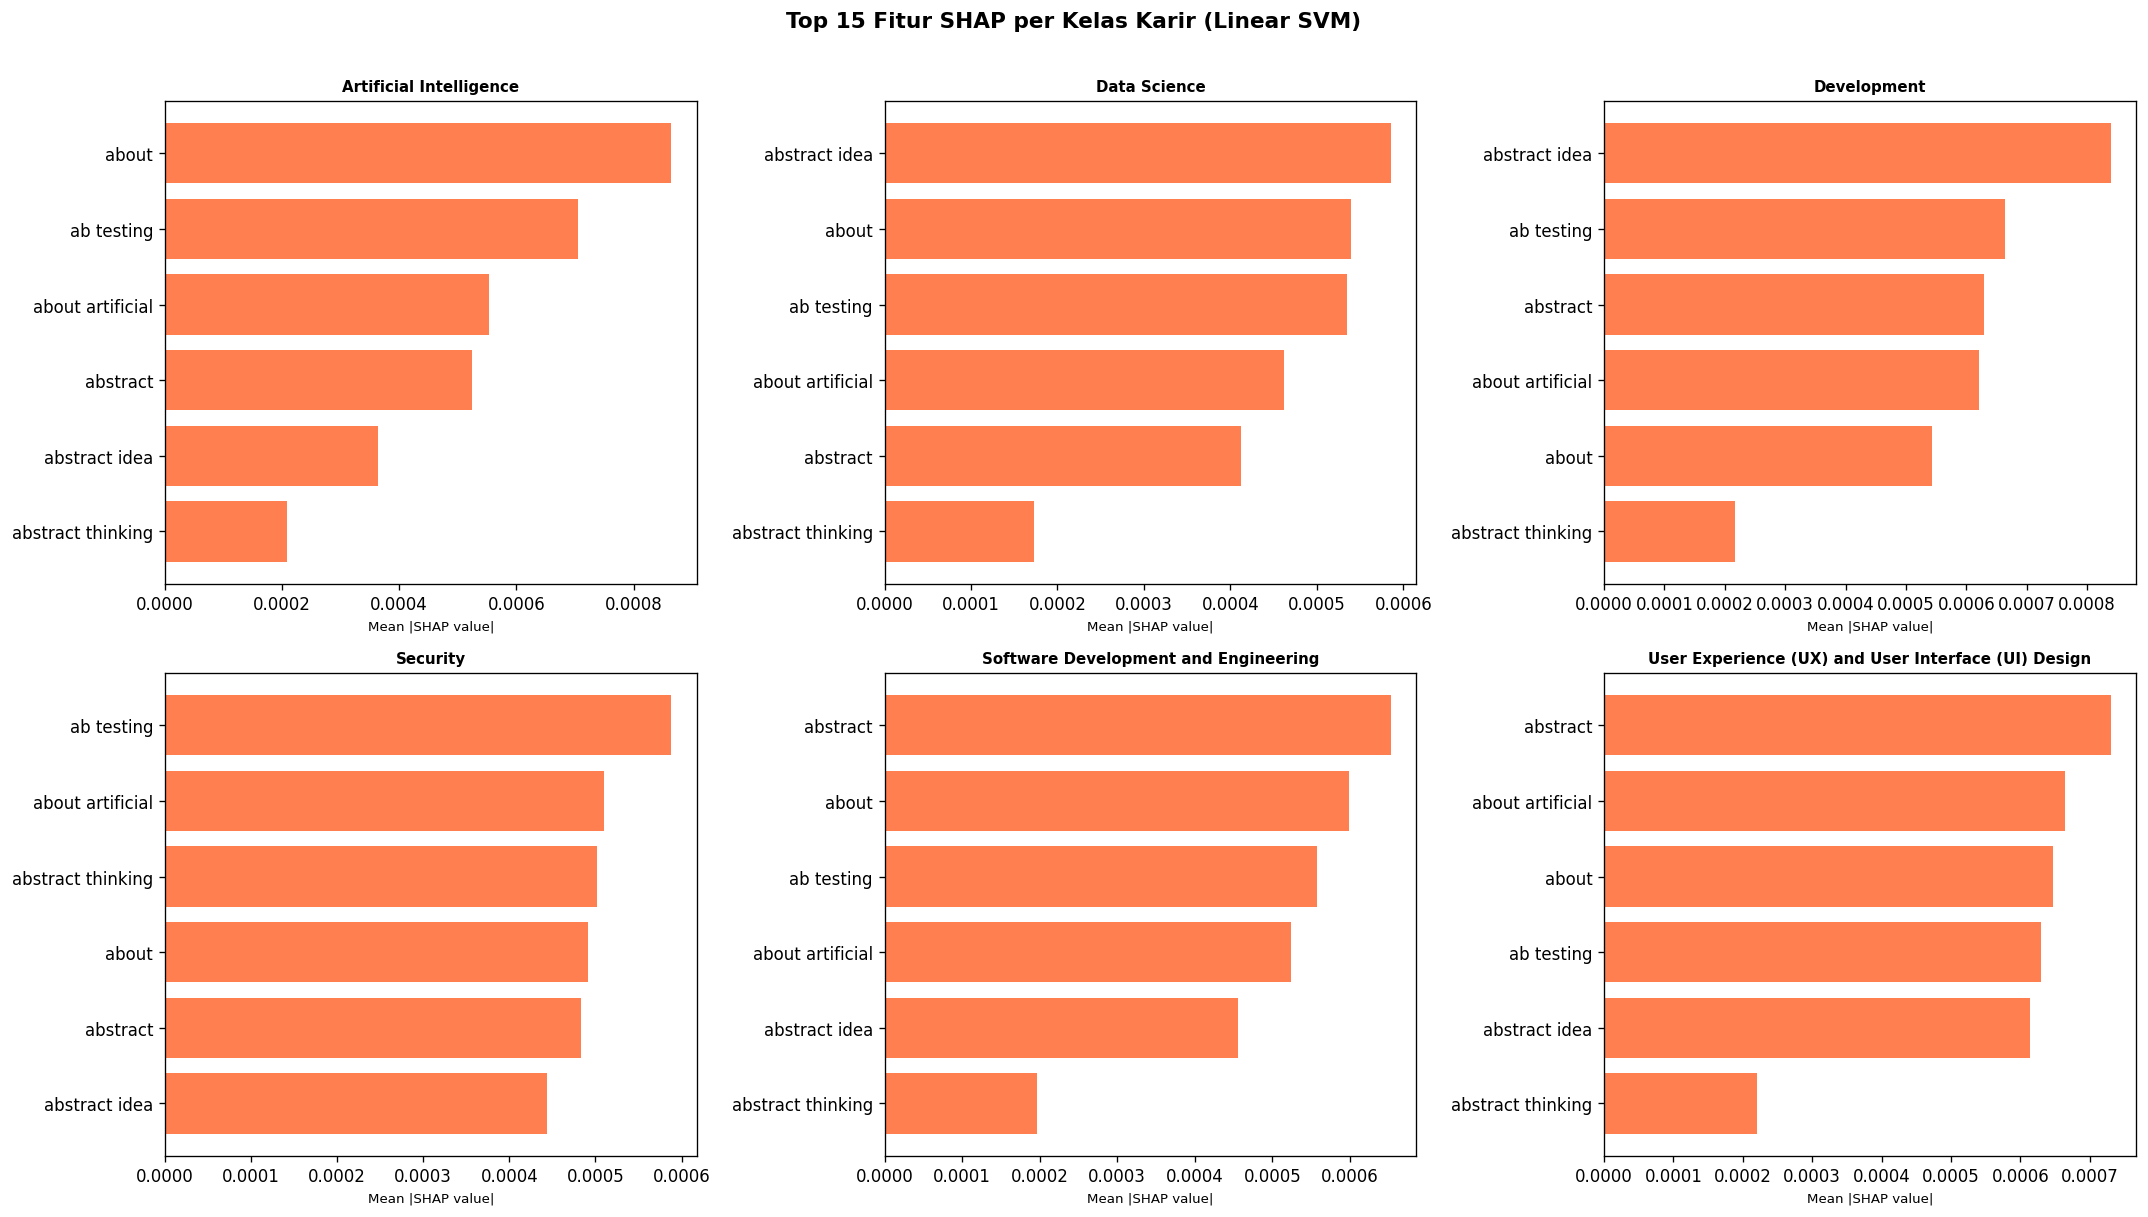

In [15]:
# ── Cell 14: Interpretability — SHAP Bar Plot per Kelas ──────────────────────
# Menampilkan top fitur berdasarkan mean |SHAP value| untuk setiap kelas karir

n_cls  = min(len(shap_vals), len(le.classes_))   # ← fix: ambil yang lebih kecil
ncols  = 3
nrows  = (n_cls + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes      = axes.flatten()

class_names = [str(c) for c in le.classes_]      # ← pastikan string (fix error sebelumnya)

for idx in range(n_cls):
    ax       = axes[idx]
    sv       = shap_vals[idx]
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[-15:][::-1]

    ax.barh(feat_names[top_idx][::-1], mean_abs[top_idx][::-1], color='coral')
    ax.set_title(class_names[idx], fontweight='bold', fontsize=9, wrap=True)  # ← class_names
    ax.set_xlabel('Mean |SHAP value|', fontsize=8)

for j in range(n_cls, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 15 Fitur SHAP per Kelas Karir (Linear SVM)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# ── Cell 15: Pilih Best Model & Demo Prediksi ─────────────────────────────────

best_name  = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']

print(f'🏆 Best Model : {best_name}')
print(f'   Accuracy   : {results[best_name]["accuracy"]:.4f}')
print(f'   F1-Macro   : {results[best_name]["f1_macro"]:.4f}')

# ── Demo prediksi ─────────────────────────────────────────────────────────────
sample_skills = [
    "machine learning deep learning python tensorflow data analysis",
    "web development react javascript html css ui ux prototyping figma",
    "penetration testing ethical hacking network security firewall kali linux",
    "flutter dart mobile app development android ios firebase",
    "data engineering pipeline sql spark cloud aws",
]

sample_clean  = [preprocess(s) for s in sample_skills]
sample_tfidf  = vectorizer.transform(sample_clean)
sample_preds  = best_model.predict(sample_tfidf)
sample_labels = le.inverse_transform(sample_preds)

print('\n📋 Demo Prediksi Karir Mahasiswa:')
print('─' * 70)
for skill, career in zip(sample_skills, sample_labels):
    print(f'  Skill   : {skill[:65]}')
    print(f'  Prediksi: {career}')
    print('  ·' * 35)

🏆 Best Model : XGBoost
   Accuracy   : 0.9522
   F1-Macro   : 0.9574

📋 Demo Prediksi Karir Mahasiswa:
──────────────────────────────────────────────────────────────────────
  Skill   : machine learning deep learning python tensorflow data analysis
  Prediksi: Data Science
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  Skill   : web development react javascript html css ui ux prototyping figma
  Prediksi: Development
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  Skill   : penetration testing ethical hacking network security firewall kal
  Prediksi: Security
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  Skill   : flutter dart mobile app development android ios firebase
  Prediksi: Development
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  Skill 

In [17]:
# ── Cell 16: Simpan & Download Model Terbaik ─────────────────────────────────
import joblib, os
from IPython.display import FileLink, display, HTML

# ── 2. Simpan model terbaik + artefak pendukung ───────────────────────────────
joblib.dump(best_model,  'model_xgb.pkl')        # best model
joblib.dump(vectorizer,  'vectorizer.pkl')        # TF-IDF vectorizer
joblib.dump(le,          'label_encoder.pkl')     # label encoder

# ── 3. Tampilkan info file ────────────────────────────────────────────────────
files = {
    'model_xgb.pkl'      : f'Best Model  ({best_name})',
    'vectorizer.pkl'     : 'TF-IDF Vectorizer',
    'label_encoder.pkl'  : 'Label Encoder',
}

print('✅ Semua file berhasil disimpan!\n')
print(f'{'File':<30} {'Keterangan':<30} {'Ukuran':>10}')
print('─' * 72)
for path, desc in files.items():
    size_kb = os.path.getsize(path) / 1024
    print(f'{path:<30} {desc:<30} {size_kb:>8.1f} KB')

# ── 4. Link download (klik langsung di Jupyter) ───────────────────────────────
print('\n📥 Klik link di bawah untuk download:')
for path in files:
    display(FileLink(path, result_html_prefix=f'⬇️  '))

# ── 5. Verifikasi: load ulang & test prediksi ─────────────────────────────────
print('\n🔍 Verifikasi model yang tersimpan...')
loaded_model      = joblib.load('model_xgb.pkl')
loaded_vectorizer = joblib.load('vectorizer.pkl')
loaded_le         = joblib.load('label_encoder.pkl')

test_input   = preprocess('machine learning deep learning python tensorflow')
test_vector  = loaded_vectorizer.transform([test_input])
test_pred    = loaded_model.predict(test_vector)
test_label   = loaded_le.inverse_transform(test_pred)[0]

print(f'  Input   : "machine learning deep learning python tensorflow"')
print(f'  Prediksi: {test_label}')
print(f'  Status  : ✅ Model siap digunakan di Streamlit!')

✅ Semua file berhasil disimpan!

File                           Keterangan                         Ukuran
────────────────────────────────────────────────────────────────────────
model_xgb.pkl                  Best Model  (XGBoost)            2386.5 KB
vectorizer.pkl                 TF-IDF Vectorizer                 219.3 KB
label_encoder.pkl              Label Encoder                       0.6 KB

📥 Klik link di bawah untuk download:


d:\BINUS\SEMESTER 4\Machine Learning\AOL\TrainingML\model_xgb.pkl

d:\BINUS\SEMESTER 4\Machine Learning\AOL\TrainingML\vectorizer.pkl

d:\BINUS\SEMESTER 4\Machine Learning\AOL\TrainingML\label_encoder.pkl


🔍 Verifikasi model yang tersimpan...
  Input   : "machine learning deep learning python tensorflow"
  Prediksi: Artificial Intelligence
  Status  : ✅ Model siap digunakan di Streamlit!
